<h1>Lab 1 Ex. 1: Image Denoising with Neural Networks</h1>

In [146]:
# from google.colab import drive
# drive.mount('/content/drive')

Unizp training and test data

In [147]:
# !unzip train_dn.zip -d train/
# !unzip test_dn.zip -d test/
from pathlib import Path

train_folder = Path("./Dataset/train_dn")
test_folder = Path("./Dataset/test_dn")

**[TODO]** Here are all the import statements needed for all the exercises

In [148]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image

**[TODO]** Create a torch dataset. It must return a tuple with a float32 tensor for the noisy image patch and another float32 tensor for the clean image patch. Patches values should be normalized.

Patch must be extracted as a 32x32 crop of the image file at a random position. Noise is additive white Gaussian noise with standard deviation equal to 25. Note that images are provided in the PNG file format.

Hint: look into torchivison transforms for random crop.

N.B.: 25 is the standard deviation on the original [0,255] scale of image intensity. If you normalize the images, be careful about it!

In [149]:
class ImageDenoisingDataset(Dataset):
    def __init__(self, folder=None, image_files=None, random_crop=True, patch_size=32, noise_std=25.0):
        self.folder = folder
        self.image_files = list(sorted(image_files)) if image_files is not None else list(sorted(folder.glob("*.png")))
        self.random_crop = random_crop
        self.patch_size = patch_size
        self.noise_std = noise_std

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert("L")

        if self.random_crop:
            w, h = image.size
            if w < self.patch_size or h < self.patch_size:
                raise ValueError(f"Image {image_path} too small for {self.patch_size}x{self.patch_size} crop")
            x = np.random.randint(0, w - self.patch_size + 1)
            y = np.random.randint(0, h - self.patch_size + 1)
            image = image.crop((x, y, x + self.patch_size, y + self.patch_size))

        # convert to numpy array
        clean_patch = np.array(image).astype(np.float32)

        # add white Gaussian noise with std 25 (in [0,255] scale)
        noise = np.random.randn(*clean_patch.shape).astype(np.float32) * self.noise_std
        noise_patch = clean_patch + noise
        noise_patch = np.clip(noise_patch, 0.0, 255.0)

        # normalize to [0, 1]
        clean_patch = clean_patch / 255.0
        noise_patch = noise_patch / 255.0

        # convert to tensors
        clean_patch = torch.from_numpy(clean_patch).float()
        noise_patch = torch.from_numpy(noise_patch).float()

        return clean_patch, noise_patch

**[TODO]** Instantiate a Dataset and create a Dataloader for the training and test sets

In [150]:
batch_size = 32

all_train_files = list(sorted(train_folder.glob("*.png")))
all_test_files = list(sorted(test_folder.glob("*.png")))

# use 10% of training files for validation (full image validation)
validation_split = 0.1
g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(all_train_files), generator=g).tolist()
num_val_samples = int(validation_split * len(all_train_files))

val_idx = perm[:num_val_samples]
train_idx = perm[num_val_samples:]

train_files = [all_train_files[i] for i in train_idx]
validation_files = [all_train_files[i] for i in val_idx]

# train: random 32x32 crops
train_dataset = ImageDenoisingDataset(image_files=train_files, random_crop=True, patch_size=32)

# validation/test: full images
validation_dataset = ImageDenoisingDataset(image_files=validation_files, random_crop=False)
test_dataset = ImageDenoisingDataset(image_files=all_test_files, random_crop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

**[TODO]** Define the neural network. You will use a shorter version of DnCNN with only 8 blocks of Conv-BN-RELU. Remember to use the residual trick. After completing the exercise, try defining a new model without the residual trick and check how it performs.

In [151]:
class shorterDnCNN(nn.Module):
    def __init__(self, num_layers=8, num_channels=64):
        super(shorterDnCNN, self).__init__()
        
        # First conv layer
        self.conv1 = nn.Conv2d(1, num_channels, 3, padding=1)
        
        # 8 Conv-BN-ReLU blocks
        layers = []
        for i in range(num_layers):
            layers.append(nn.Conv2d(num_channels, num_channels, 3, padding=1))
            layers.append(nn.BatchNorm2d(num_channels))
            layers.append(nn.ReLU(inplace=True))
        self.blocks = nn.Sequential(*layers)
        
        # Last conv layer (output noise map)
        self.conv_last = nn.Conv2d(num_channels, 1, 3, padding=1)
    
    def forward(self, x):
        residual = x  # Save INPUT
        x = self.conv1(x)
        x = self.blocks(x)  # Process through 8 blocks
        x = self.conv_last(x)
        return residual - x  # Skip connection: INPUT - OUTPUT
    
class shorterDnCNN_without_residual(nn.Module):
    def __init__(self, num_layers=8, num_channels=64):
        super(shorterDnCNN_without_residual, self).__init__()
        
        # First conv layer
        self.conv1 = nn.Conv2d(1, num_channels, 3, padding=1)
        
        # 8 Conv-BN-ReLU blocks
        layers = []
        for i in range(num_layers):
            layers.append(nn.Conv2d(num_channels, num_channels, 3, padding=1))
            layers.append(nn.BatchNorm2d(num_channels))
            layers.append(nn.ReLU(inplace=True))
        self.blocks = nn.Sequential(*layers)
        
        # Last conv layer (output noise map)
        self.conv_last = nn.Conv2d(num_channels, 1, 3, padding=1)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.blocks(x)  # Process through 8 blocks
        x = self.conv_last(x)
        return x  # No residual connection

**[TODO]** Instantiate the DnCNN model, move it GPU, and define an optimizer

In [152]:
model = shorterDnCNN()
print(model)

shorterDnCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (blocks): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, mom

In [153]:
model_without_residual = shorterDnCNN_without_residual()
print(model_without_residual)

shorterDnCNN_without_residual(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (blocks): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(6

**[TODO]** Train the model

In [154]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device} for model with residual connection")

criterion = nn.MSELoss()  # Mean Squared Error loss for regression tasks like denoising
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer with a learning rate of 0.001 (optimized version of SGD)
num_epochs = 30
best_val_loss = float('inf')
avg_val_losses = []
avg_train_losses = []

# Early stopping parameters
patience = 5  # number of epochs to wait for improvement before stopping
patience_counter = 0  # counter to track epochs without improvement

model.to(device)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for clean_patches, noise_patches in train_loader:
        # grayscale patches are (B, H, W) -> convert to (B, C, H, W) with C=1
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(noise_patches)
        loss = criterion(outputs, clean_patches)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * clean_patches.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    total = 0
    correct = 0
    with torch.no_grad():
        for clean_patches, noise_patches in validation_loader:
            clean_patches = clean_patches.unsqueeze(1).to(device)
            noise_patches = noise_patches.unsqueeze(1).to(device)

            outputs = model(noise_patches)
            loss = criterion(outputs, clean_patches)
            val_loss += loss.item() * clean_patches.size(0)

    avg_val_loss = val_loss / len(validation_loader.dataset)
    avg_val_losses.append(avg_val_loss)

    # if validation loss improves, save model and reset counter
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0  # reset counter
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
        }, './best_model.pth')
        print(f'\nValidation loss improved to {best_val_loss:.4f}, model saved.')

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            print(f'Best validation loss: {best_val_loss:.4f}')
            break

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Best Val Loss: {best_val_loss:.4f}, Patience Counter: {patience_counter}/{patience}")

Using device cpu for model with residual connection

Validation loss improved to 0.0095, model saved.
Epoch [1/30], Train Loss: 0.0440, Val Loss: 0.0095, Best Val Loss: 0.0095, Patience Counter: 0/5

Validation loss improved to 0.0083, model saved.
Epoch [2/30], Train Loss: 0.0087, Val Loss: 0.0083, Best Val Loss: 0.0083, Patience Counter: 0/5

Validation loss improved to 0.0058, model saved.
Epoch [3/30], Train Loss: 0.0067, Val Loss: 0.0058, Best Val Loss: 0.0058, Patience Counter: 0/5

Validation loss improved to 0.0051, model saved.
Epoch [4/30], Train Loss: 0.0052, Val Loss: 0.0051, Best Val Loss: 0.0051, Patience Counter: 0/5

Validation loss improved to 0.0044, model saved.
Epoch [5/30], Train Loss: 0.0040, Val Loss: 0.0044, Best Val Loss: 0.0044, Patience Counter: 0/5

Validation loss improved to 0.0031, model saved.
Epoch [6/30], Train Loss: 0.0036, Val Loss: 0.0031, Best Val Loss: 0.0031, Patience Counter: 0/5
Epoch [7/30], Train Loss: 0.0034, Val Loss: 0.0040, Best Val Loss:

In [155]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device} for model without residual connection")

criterion = nn.MSELoss()  # Mean Squared Error loss for regression tasks like denoising
optimizer = torch.optim.Adam(model_without_residual.parameters(), lr=0.001)  # Adam optimizer with a learning rate of 0.001 (optimized version of SGD)
num_epochs = 30
best_val_loss = float('inf')
avg_val_losses_without_residual = []
avg_train_losses_without_residual = []

# Early stopping parameters
patience = 5  # number of epochs to wait for improvement before stopping
patience_counter = 0  # counter to track epochs without improvement

model_without_residual.to(device)

for epoch in range(num_epochs):
    model_without_residual.train()
    train_loss = 0.0
    for clean_patches, noise_patches in train_loader:
        # grayscale patches are (B, H, W) -> convert to (B, C, H, W) with C=1
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model_without_residual(noise_patches)
        loss = criterion(outputs, clean_patches)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * clean_patches.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_losses_without_residual.append(avg_train_loss)

    model_without_residual.eval()
    val_loss = 0.0
    total = 0
    correct = 0
    with torch.no_grad():
        for clean_patches, noise_patches in validation_loader:
            clean_patches = clean_patches.unsqueeze(1).to(device)
            noise_patches = noise_patches.unsqueeze(1).to(device)

            outputs = model_without_residual(noise_patches)
            loss = criterion(outputs, clean_patches)
            val_loss += loss.item() * clean_patches.size(0)

    avg_val_loss = val_loss / len(validation_loader.dataset)
    avg_val_losses_without_residual.append(avg_val_loss)

    # if validation loss improves, save model and reset counter
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0  # reset counter
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_without_residual.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
        }, './best_model_without_residual.pth')
        print(f'\nValidation loss improved to {best_val_loss:.4f}, model saved.')

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            print(f'Best validation loss: {best_val_loss:.4f}')
            break

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Best Val Loss: {best_val_loss:.4f}, Patience Counter: {patience_counter}/{patience}")

Using device cpu for model without residual connection

Validation loss improved to 0.0348, model saved.
Epoch [1/30], Train Loss: 0.1640, Val Loss: 0.0348, Best Val Loss: 0.0348, Patience Counter: 0/5
Epoch [2/30], Train Loss: 0.0271, Val Loss: 0.3119, Best Val Loss: 0.0348, Patience Counter: 1/5
Epoch [3/30], Train Loss: 0.0146, Val Loss: 0.0388, Best Val Loss: 0.0348, Patience Counter: 2/5

Validation loss improved to 0.0067, model saved.
Epoch [4/30], Train Loss: 0.0096, Val Loss: 0.0067, Best Val Loss: 0.0067, Patience Counter: 0/5
Epoch [5/30], Train Loss: 0.0094, Val Loss: 0.0147, Best Val Loss: 0.0067, Patience Counter: 1/5
Epoch [6/30], Train Loss: 0.0082, Val Loss: 0.0117, Best Val Loss: 0.0067, Patience Counter: 2/5

Validation loss improved to 0.0062, model saved.
Epoch [7/30], Train Loss: 0.0065, Val Loss: 0.0062, Best Val Loss: 0.0062, Patience Counter: 0/5
Epoch [8/30], Train Loss: 0.0087, Val Loss: 0.0109, Best Val Loss: 0.0062, Patience Counter: 1/5

Validation loss im

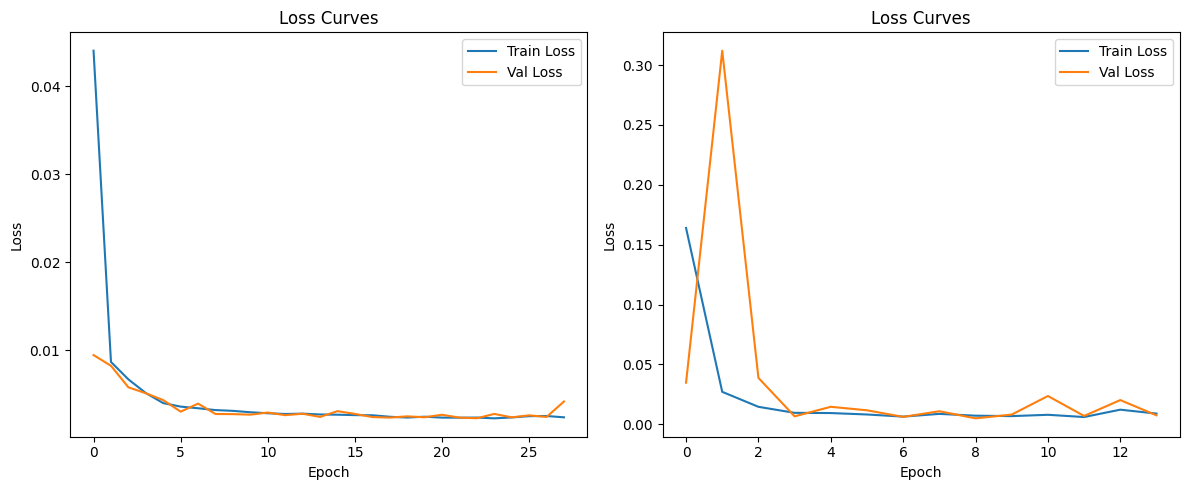

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)    # val and train loss curves
plt.plot(avg_train_losses, label='Train Loss')
plt.plot(avg_val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)    # val accuracy curve
plt.plot(avg_train_losses_without_residual, label='Train Loss')
plt.plot(avg_val_losses_without_residual, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.legend()
plt.tight_layout()
plt.show()

**[TODO]** Test the denoiser on the test images. Load an image, corrupt it with noise and use the model to denoise it. Measure the PSNR in dB of the denoised image with respect to the clean one. Visualize a clean, noisy and denoised image.

In [157]:
checkpoint = torch.load('./best_model.pth', map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
best_val_loss = checkpoint['val_loss']
print(f'\nLoaded model from epoch {checkpoint["epoch"]} with validation loss {best_val_loss:.4f}')

checkpoint_without_residual = torch.load('./best_model_without_residual.pth', map_location=torch.device(device))
model_without_residual.load_state_dict(checkpoint_without_residual['model_state_dict'])
optimizer.load_state_dict(checkpoint_without_residual['optimizer_state_dict'])
start_epoch = checkpoint_without_residual['epoch'] + 1
best_val_loss = checkpoint_without_residual['val_loss']
print(f'\nLoaded model from epoch {checkpoint_without_residual["epoch"]} with validation loss {best_val_loss:.4f}')


Loaded model from epoch 22 with validation loss 0.0023

Loaded model from epoch 8 with validation loss 0.0050


In [158]:
# compute the PSNR of noisy test image respect to its clean version
def compute_psnr(clean, noisy):
    mse = torch.mean((clean - noisy) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * torch.log10(1 / mse)
    return psnr.item()

# compute the PSNR of denoised test image respect to its clean version
def compute_psnr_denoised(clean, denoised):
    mse = torch.mean((clean - denoised) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * torch.log10(1 / mse)
    return psnr.item()

psnr_noisy = []
psnr_denoised_with_residual = []
psnr_denoised_without_residual = []

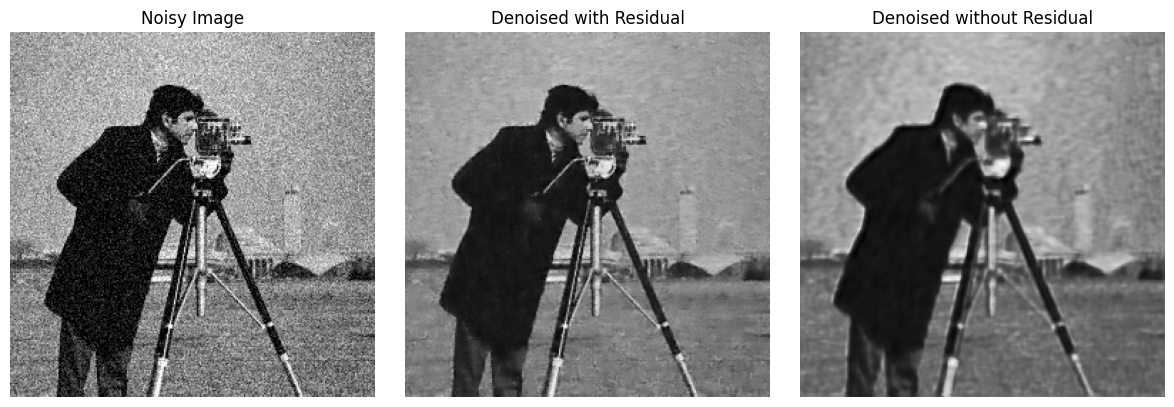


Test Loss with residual connection: 0.0019
Test Loss without residual connection: 0.0044
Average PSNR of Noisy Patches: 20.33 dB
Average PSNR of Denoised Patches with Residual Connection: 27.27 dB
Average PSNR of Denoised Patches without Residual Connection: 23.69 dB


In [159]:
test_loss = 0.0
test_loss_without_residual = 0.0

model.eval()
model_without_residual.eval()

with torch.no_grad():
    for clean_patches, noise_patches in test_loader:
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        outputs = model(noise_patches)
        outputs_without_residual = model_without_residual(noise_patches)

        # show first full test image (noisy vs denoised with/without residual)
        if test_loss == 0.0:
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

            axes[0].imshow(noise_patches[0].cpu().squeeze(), cmap='gray')
            axes[0].set_title('Noisy Image')
            axes[0].axis('off')

            axes[1].imshow(outputs[0].cpu().squeeze(), cmap='gray')
            axes[1].set_title('Denoised with Residual')
            axes[1].axis('off')

            axes[2].imshow(outputs_without_residual[0].cpu().squeeze(), cmap='gray')
            axes[2].set_title('Denoised without Residual')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

        loss = criterion(outputs, clean_patches)
        loss_without_residual = criterion(outputs_without_residual, clean_patches)

        test_loss += loss.item() * noise_patches.size(0)
        test_loss_without_residual += loss_without_residual.item() * noise_patches.size(0)

        psnr_noisy.append(compute_psnr(clean_patches, noise_patches))
        psnr_denoised_with_residual.append(compute_psnr_denoised(clean_patches, outputs))
        psnr_denoised_without_residual.append(compute_psnr_denoised(clean_patches, outputs_without_residual))

avg_test_loss = test_loss / len(test_loader.dataset)
avg_test_loss_without_residual = test_loss_without_residual / len(test_loader.dataset)
avg_psnr_noisy = np.mean(psnr_noisy)
avg_psnr_denoised_with_residual = np.mean(psnr_denoised_with_residual)
avg_psnr_denoised_without_residual = np.mean(psnr_denoised_without_residual)

print(f'\nTest Loss with residual connection: {avg_test_loss:.4f}')
print(f'Test Loss without residual connection: {avg_test_loss_without_residual:.4f}')

print(f'Average PSNR of Noisy Patches: {avg_psnr_noisy:.2f} dB')
print(f'Average PSNR of Denoised Patches with Residual Connection: {avg_psnr_denoised_with_residual:.2f} dB')
print(f'Average PSNR of Denoised Patches without Residual Connection: {avg_psnr_denoised_without_residual:.2f} dB')

**[TODO]** Test the pretrained network with the residual trick on test images where the noise has
standard deviation equal to 10 and to 50 and report the resulting PSNRs

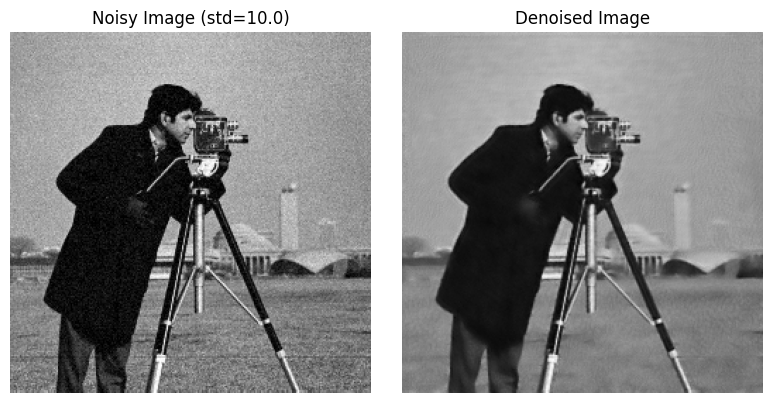


Noise STD: 10.0, Average PSNR of Noisy Patches: 28.16 dB, Average PSNR of Denoised Patches: 28.73 dB


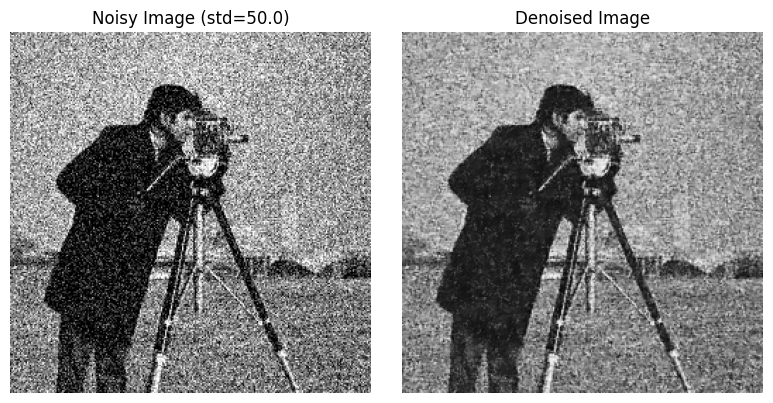


Noise STD: 50.0, Average PSNR of Noisy Patches: 14.77 dB, Average PSNR of Denoised Patches: 18.89 dB


In [161]:
# Test the pretrained network with the residual trick on test images where the noise has standard deviation equal to 10 and to 50 and report the resulting PSNRs

model.eval()

def test_with_different_noise_levels(model, noise_std):
    psnr_noisy = []
    psnr_denoised = []

    with torch.no_grad():
        for clean_patches, _ in test_loader:
            clean_patches = clean_patches.unsqueeze(1).to(device)

            # add noise with specified std
            noise = torch.randn_like(clean_patches) * (noise_std / 255.0)
            noisy_patches = clean_patches + noise
            noisy_patches = torch.clamp(noisy_patches, 0.0, 1.0)

            outputs = model(noisy_patches)

            # show first full test image (noisy vs denoised)
            if len(psnr_noisy) == 0:
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))

                axes[0].imshow(noisy_patches[0].cpu().squeeze(), cmap='gray')
                axes[0].set_title(f'Noisy Image (std={noise_std})')
                axes[0].axis('off')

                axes[1].imshow(outputs[0].cpu().squeeze(), cmap='gray')
                axes[1].set_title('Denoised Image')
                axes[1].axis('off')

                plt.tight_layout()
                plt.show()

            psnr_noisy.append(compute_psnr(clean_patches, noisy_patches))
            psnr_denoised.append(compute_psnr_denoised(clean_patches, outputs))

    avg_psnr_noisy = np.mean(psnr_noisy)
    avg_psnr_denoised = np.mean(psnr_denoised)

    print(f'\nNoise STD: {noise_std}, Average PSNR of Noisy Patches: {avg_psnr_noisy:.2f} dB, Average PSNR of Denoised Patches: {avg_psnr_denoised:.2f} dB')

test_with_different_noise_levels(model, noise_std=10.0)
test_with_different_noise_levels(model, noise_std=50.0)

**[TODO]** Now train a new DnCNN where the dataloader chooses the standard deviation
uniformly at random in the [10,50] interval instead of fixing it to 25, for each batch item
(this is called blind training). Test it on test images with standard deviations 10, 25, 50.

In [162]:
# Now train a new DnCNN where the dataloader chooses the standard deviation uniformly at random in the [10,50] interval instead of fixing it to 25, for each batch item (this is called blind training). Test it on test images with standard deviations 10, 25, 50.

class ImageDenoisingDatasetBlind(Dataset):
    def __init__(self, folder=None, image_files=None, random_crop=True, patch_size=32, noise_std_range=(10.0, 50.0)):
        self.folder = folder
        self.image_files = list(sorted(image_files)) if image_files is not None else list(sorted(folder.glob("*.png")))
        self.random_crop = random_crop
        self.patch_size = patch_size
        self.noise_std_range = noise_std_range

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert("L")

        if self.random_crop:
            w, h = image.size
            if w < self.patch_size or h < self.patch_size:
                raise ValueError(f"Image {image_path} too small for {self.patch_size}x{self.patch_size} crop")
            x = np.random.randint(0, w - self.patch_size + 1)
            y = np.random.randint(0, h - self.patch_size + 1)
            image = image.crop((x, y, x + self.patch_size, y + self.patch_size))

        # convert to numpy array
        clean_patch = np.array(image).astype(np.float32)

        # randomly choose noise std in the specified range
        noise_std = np.random.uniform(self.noise_std_range[0], self.noise_std_range[1])
        
        # add white Gaussian noise with the chosen std (in [0,255] scale)
        noise = np.random.randn(*clean_patch.shape).astype(np.float32) * noise_std
        noise_patch = clean_patch + noise
        noise_patch = np.clip(noise_patch, 0.0, 255.0)

        # normalize to [0, 1]
        clean_patch = clean_patch / 255.0
        noise_patch = noise_patch / 255.0

        # convert to tensors
        clean_patch = torch.from_numpy(clean_patch).float()
        noise_patch = torch.from_numpy(noise_patch).float()

        return clean_patch, noise_patch

# Create new datasets and dataloaders for blind training
train_dataset_blind = ImageDenoisingDatasetBlind(image_files=train_files, random_crop=True, patch_size=32)
validation_dataset_blind = ImageDenoisingDatasetBlind(image_files=validation_files, random_crop=False)
test_dataset_blind = ImageDenoisingDatasetBlind(image_files=all_test_files, random_crop=False)

train_loader_blind = DataLoader(train_dataset_blind, batch_size=batch_size, shuffle=True)
validation_loader_blind = DataLoader(validation_dataset_blind, batch_size=1, shuffle=False)
test_loader_blind = DataLoader(test_dataset_blind, batch_size=1, shuffle=False)

In [163]:
model_blind = shorterDnCNN()
model_blind.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_blind.parameters(), lr=0.001)
num_epochs = 30
best_val_loss = float('inf')
avg_val_losses_blind = []
avg_train_losses_blind = []

# Early stopping parameters
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    model_blind.train()
    train_loss = 0.0
    for clean_patches, noise_patches in train_loader_blind:
        clean_patches = clean_patches.unsqueeze(1).to(device)
        noise_patches = noise_patches.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model_blind(noise_patches)
        loss = criterion(outputs, clean_patches)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * clean_patches.size(0)

    avg_train_loss = train_loss / len(train_loader_blind.dataset)
    avg_train_losses_blind.append(avg_train_loss)

    model_blind.eval()
    val_loss = 0.0
    with torch.no_grad():
        for clean_patches, noise_patches in validation_loader_blind:
            clean_patches = clean_patches.unsqueeze(1).to(device)
            noise_patches = noise_patches.unsqueeze(1).to(device)

            outputs = model_blind(noise_patches)
            loss = criterion(outputs, clean_patches)
            val_loss += loss.item() * clean_patches.size(0)

    avg_val_loss = val_loss / len(validation_loader_blind.dataset)
    avg_val_losses_blind.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_blind.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
        }, './best_model_blind.pth')
        print(f'\nValidation loss improved to {best_val_loss:.4f}, model saved.')

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            print(f'Best validation loss: {best_val_loss:.4f}')
            break

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Best Val Loss: {best_val_loss:.4f}, Patience Counter: {patience_counter}/{patience}")


Validation loss improved to 0.0207, model saved.
Epoch [1/30], Train Loss: 0.0890, Val Loss: 0.0207, Best Val Loss: 0.0207, Patience Counter: 0/5

Validation loss improved to 0.0162, model saved.
Epoch [2/30], Train Loss: 0.0133, Val Loss: 0.0162, Best Val Loss: 0.0162, Patience Counter: 0/5

Validation loss improved to 0.0073, model saved.
Epoch [3/30], Train Loss: 0.0098, Val Loss: 0.0073, Best Val Loss: 0.0073, Patience Counter: 0/5

Validation loss improved to 0.0058, model saved.
Epoch [4/30], Train Loss: 0.0075, Val Loss: 0.0058, Best Val Loss: 0.0058, Patience Counter: 0/5

Validation loss improved to 0.0055, model saved.
Epoch [5/30], Train Loss: 0.0065, Val Loss: 0.0055, Best Val Loss: 0.0055, Patience Counter: 0/5

Validation loss improved to 0.0052, model saved.
Epoch [6/30], Train Loss: 0.0056, Val Loss: 0.0052, Best Val Loss: 0.0052, Patience Counter: 0/5

Validation loss improved to 0.0049, model saved.
Epoch [7/30], Train Loss: 0.0053, Val Loss: 0.0049, Best Val Loss: 0

KeyboardInterrupt: 


Loaded model from epoch 15 with validation loss 0.0034


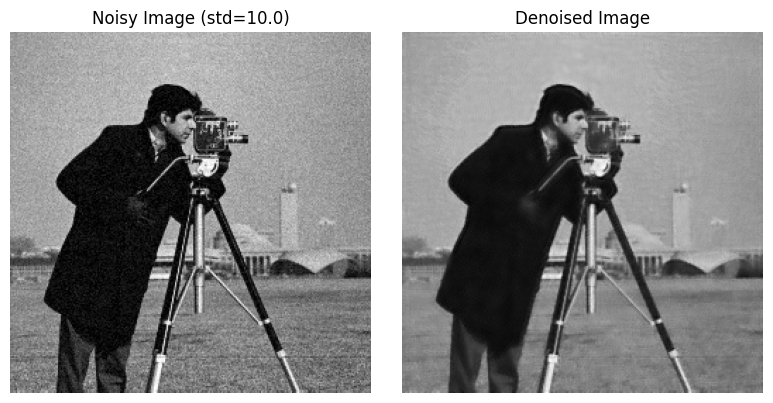


Noise STD: 10.0, Average PSNR of Noisy Patches: 28.16 dB, Average PSNR of Denoised Patches: 29.72 dB


KeyboardInterrupt: 

In [164]:
checkpoint_blind = torch.load('./best_model_blind.pth', map_location=torch.device(device))
model_blind.load_state_dict(checkpoint_blind['model_state_dict'])
optimizer.load_state_dict(checkpoint_blind['optimizer_state_dict'])
start_epoch = checkpoint_blind['epoch'] + 1
best_val_loss = checkpoint_blind['val_loss']
print(f'\nLoaded model from epoch {checkpoint_blind["epoch"]} with validation loss {best_val_loss:.4f}')

for noise_std in [10.0, 25.0, 50.0]:
    test_with_different_noise_levels(model_blind, noise_std)